#Interpolação Temporal do ERA5 x LiDAR
####Para essa fase exploratória da pesquisa, pretendo validar as métricas de erro do Era5 em relação ao Lidar, para isso pretendo usar duas principais abordagem para alinhamento temporal.

###Abordagem A: Janela Tradicional (Sem Deslocamento)
#####Como fica o alinhamento: O valor do LiDAR no timestamp 18:00 será a média de tudo o que aconteceu entre 18:00 e 18:50.

--- RESULTADOS (Média do LiDAR recortada - Abordagem A) ---
Período Analisado: 2021-09-16 21:00:00 até 2021-11-08 14:00:00 (UTC)
Total de horas coincidentes: 1266
Coeficiente de Correlação de Pearson: 0.6636
Erro Médio Absoluto (MAE): 1.5388 m/s
Raiz do Erro Quadrático Médio (RMSE): 1.8062 m/s



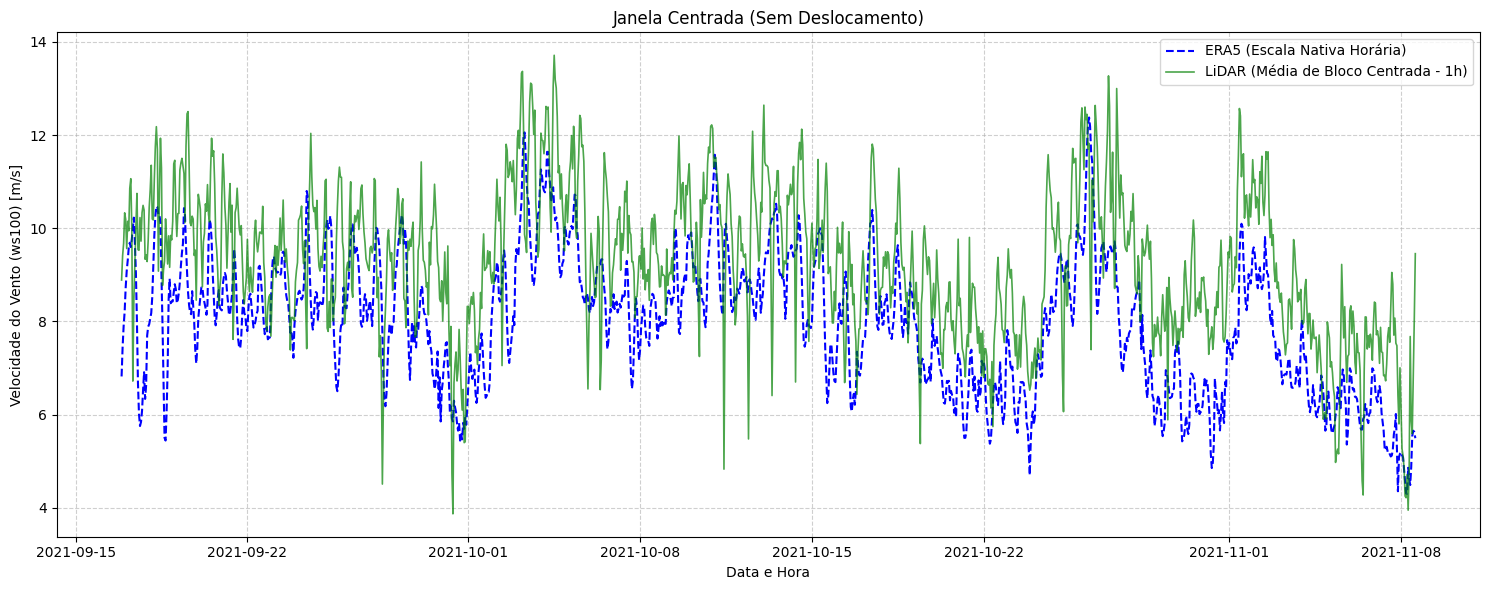

In [4]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

data_path = '/content/data/era5_dataset.nc'
ds_era5 = xr.open_dataset(data_path)
df_lidar = pd.read_csv('/content/data/dataset.csv')

colunas_interesse = ['d2m', 't2m', 'sp', 'u100', 'v100', 'z']
colunas_presentes = [c for c in colunas_interesse if c in ds_era5.data_vars]
ds_era5['ws100'] = (ds_era5.u100**2 + ds_era5.v100**2)**0.5
era5_ponto = ds_era5.sel(latitude=-2.69, longitude=-42.56, method='nearest')
era5_periodo = era5_ponto.ws100.sel(valid_time=slice('2021-09-15', '2021-11-08'))
ds_10min = era5_periodo.resample(valid_time='10min').interpolate('linear')

df_lidar['valid_time'] = pd.to_datetime(df_lidar[['year', 'month', 'day', 'hour', 'minute']])
df_lidar['valid_time'] = df_lidar['valid_time'] + pd.Timedelta(hours=3) # Conversão do UTC
df_lidar = df_lidar.set_index('valid_time')
lidar_periodo = df_lidar['ws100'].loc['2021-09-15':'2021-11-08']

#lidar_horario = df_lidar[['ws100']].resample('1h', offset='30min').mean() Calculo com deslocamento TESTE
lidar_horario = df_lidar[['ws100']].resample('1h').mean()

# Deslocamos o índice resultante em +30 minutos para frente. TESTE
# lidar_horario.index = lidar_horario.index + pd.Timedelta(minutes=30) TESTE
df_lidar_final = lidar_horario.rename(columns={'ws100': 'ws100_lidar'})

# Prepara o ERA5 data for join
df_era5_final = era5_periodo.to_dataframe().reset_index().set_index('valid_time')
df_era5_final = df_era5_final.rename(columns={'ws100': 'ws100_era5'}).drop(columns=['number', 'latitude', 'longitude'])

# Alinhamento Perfeito por Interseção (Inner Join)
# Isso garante que apenas os timestamps presentes em ambos os datasets (período do LiDAR) sejam avaliados
df_analise = df_era5_final.join(df_lidar_final, how='inner')

# Filtragem explícita para garantir o escopo do LiDAR fornecido
df_analise = df_analise.loc['2021-09-16 18:00:00':'2021-11-08 14:00:00']

# Cálculo das Métricas Estatísticas
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

correlacao = df_analise['ws100_era5'].corr(df_analise['ws100_lidar'])
mae = mean_absolute_error(df_analise['ws100_lidar'], df_analise['ws100_era5'])
rmse = root_mean_squared_error(df_analise['ws100_lidar'], df_analise['ws100_era5'])

print(f"--- RESULTADOS (Média do LiDAR recortada - Abordagem A) ---")
print(f"Período Analisado: {df_analise.index.min()} até {df_analise.index.max()} (UTC)")
print(f"Total de horas coincidentes: {len(df_analise)}")
print(f"Coeficiente de Correlação de Pearson: {correlacao:.4f}")
print(f"Erro Médio Absoluto (MAE): {mae:.4f} m/s")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f} m/s\n")

# Construção do Gráfico Comparativo com Marcadores de Coincidência
plt.figure(figsize=(15, 6))
plt.plot(df_analise.index, df_analise['ws100_era5'],label='ERA5 (Escala Nativa Horária)',color='blue', lw=1.5, markersize=4,linestyle='--', markerfacecolor='black')
plt.plot(df_analise.index, df_analise['ws100_lidar'],label='LiDAR (Média de Bloco Centrada - 1h)',color='green', alpha=0.7, lw=1.2, markersize=4, markerfacecolor='red')

plt.xlabel('Data e Hora')
plt.ylabel('Velocidade do Vento (ws100) [m/s]')
plt.title('Janela Centrada (Sem Deslocamento)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###Abordagem B: ERA5 Interpolado
#####Como fica o alinhamento: O valor do ERA5 é esticado de 1h para 10min acompanhando o LiDAR.

--- RESULTADOS (ERA5 Interpolado para 10min - Abordagem B) ---
Período Analisado: 2021-09-16 21:00:00 até 2021-11-08 17:20:00 (UTC)
Total de pontos (10 min): 4195
Correlação de Pearson: 0.6248
Erro Médio Absoluto (MAE): 1.5996 m/s
Raiz do Erro Quadrático Médio (RMSE): 1.8983 m/s



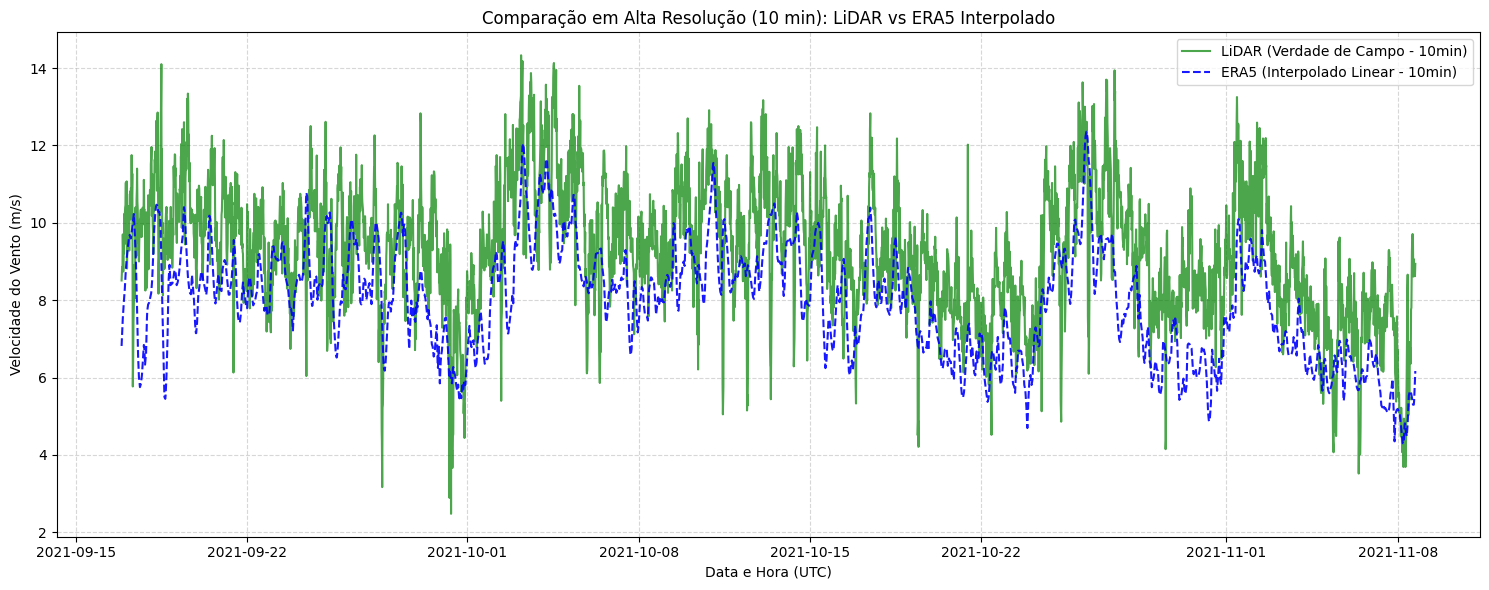

In [6]:

# Utiliza-se a interpolação linear por ser considerada a mais robusta
era5_10min = era5_ponto.ws100.resample(valid_time='10min').interpolate('linear')
df_era5_final = era5_10min.to_dataframe().reset_index().set_index('valid_time')
df_era5_final = df_era5_final.rename(columns={'ws100': 'ws100_era5'})

# Processamento do LiDAR (Resolução nativa: 10min, padrão Local UTC-3)
df_lidar['valid_time'] = pd.to_datetime(df_lidar[['year', 'month', 'day', 'hour', 'minute']])
df_lidar = df_lidar.set_index('valid_time')

# AJUSTE UTC: Adicionamos 3 horas ao LiDAR para alinhar cronologicamente com o ERA5 assim como antes
df_lidar.index = df_lidar.index + pd.Timedelta(hours=3)
df_lidar_final = df_lidar[['ws100']].rename(columns={'ws100': 'ws100_lidar'})

# Alinhamento por Interseção (Inner Join)
# Mantém a resolução de 10 minutos, preservando a variabilidade real do sensor
df_analise = df_era5_final.join(df_lidar_final, how='inner')

# Filtragem do período de estudo
df_analise = df_analise.loc['2021-09-16':'2021-11-08']

# Cálculo das Métricas Estatísticas
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

correlacao = df_analise['ws100_era5'].corr(df_analise['ws100_lidar'])
mae = mean_absolute_error(df_analise['ws100_lidar'], df_era5_final.loc[df_analise.index, 'ws100_era5'])
rmse = root_mean_squared_error(df_analise['ws100_lidar'], df_era5_final.loc[df_analise.index, 'ws100_era5'])

print(f"--- RESULTADOS (ERA5 Interpolado para 10min - Abordagem B) ---")
print(f"Período Analisado: {df_analise.index.min()} até {df_analise.index.max()} (UTC)")
print(f"Total de pontos (10 min): {len(df_analise)}")
print(f"Correlação de Pearson: {correlacao:.4f}")
print(f"Erro Médio Absoluto (MAE): {mae:.4f} m/s")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f} m/s\n")

#Visualização Gráfica
plt.figure(figsize=(15, 6))
plt.plot(df_analise.index, df_analise['ws100_lidar'], label='LiDAR (Verdade de Campo - 10min)', color='green', alpha=0.7)
plt.plot(df_analise.index, df_analise['ws100_era5'], label='ERA5 (Interpolado Linear - 10min)', color='blue', linestyle='--', alpha=0.9)

plt.xlabel('Data e Hora (UTC)')
plt.ylabel('Velocidade do Vento (m/s)')
plt.title('Comparação em Alta Resolução (10 min): LiDAR vs ERA5 Interpolado')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()